In [1]:
!git clone https://github.com/spMohanty/PlantVillage-Dataset.git

Cloning into 'PlantVillage-Dataset'...
remote: Enumerating objects: 163264, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 163264 (delta 16), reused 25 (delta 9), pack-reused 163229 (from 1)
Receiving objects: 100% (163264/163264), 2.00 GiB | 33.07 MiB/s, done.
Resolving deltas: 100% (115/115), done.
Updating files: 100% (182404/182404), done.


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

from PIL import Image
import matplotlib.pyplot as plt

In [3]:
dataset_path = "/content/PlantVillage-Dataset/raw/color"

In [4]:
full_dataset = datasets.ImageFolder(dataset_path)

print("Total images:", len(full_dataset))
print("Total classes:", len(full_dataset.classes))

Total images: 54305
Total classes: 38


In [5]:
tomato_classes = [
    name
    for name in full_dataset.classes
    if name.startswith("Tomato___")
]

print("Tomato classes:")

for name in tomato_classes:
    print(name)

print("Number of tomato classes:", len(tomato_classes))

Tomato classes:
Tomato___Bacterial_spot
Tomato___Early_blight
Tomato___Late_blight
Tomato___Leaf_Mold
Tomato___Septoria_leaf_spot
Tomato___Spider_mites Two-spotted_spider_mite
Tomato___Target_Spot
Tomato___Tomato_Yellow_Leaf_Curl_Virus
Tomato___Tomato_mosaic_virus
Tomato___healthy
Number of tomato classes: 10


In [6]:
tomato_paths = []
tomato_labels = []

class_to_id = {
    name: i
    for i, name in enumerate(tomato_classes)
}

for image_path, label in full_dataset.samples:

    class_name = full_dataset.classes[label]

    if class_name.startswith("Tomato___"):

        tomato_paths.append(image_path)

        tomato_labels.append(
            class_to_id[class_name]
        )

print("Total tomato images:", len(tomato_paths))

Total tomato images: 18160


In [7]:
train_paths, test_paths, train_labels, test_labels = train_test_split(
    tomato_paths,
    tomato_labels,
    test_size=0.20,
    random_state=42,
    stratify=tomato_labels
)

print("Training images:", len(train_paths))
print("Testing images:", len(test_paths))

Training images: 14528
Testing images: 3632


In [8]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

In [9]:
class TomatoDataset(Dataset):

    def __init__(self, paths, labels, transform):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, index):

        image = Image.open(
            self.paths[index]
        ).convert("RGB")

        image = self.transform(image)

        label = self.labels[index]

        return image, label

In [10]:
train_dataset = TomatoDataset(
    train_paths,
    train_labels,
    transform
)

test_dataset = TomatoDataset(
    test_paths,
    test_labels,
    transform
)

In [11]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

In [12]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Using:", device)

Using: cuda


In [13]:
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

In [14]:
class SimpleCNN(nn.Module):

    def __init__(self, num_classes):

        super().__init__()

        self.conv1 = nn.Conv2d(
            3, 8,
            kernel_size=3,
            padding=1
        )

        self.conv2 = nn.Conv2d(
            8, 16,
            kernel_size=3,
            padding=1
        )

        self.pool = nn.MaxPool2d(
            2, 2
        )

        self.flatten = nn.Flatten()

        self.fc = nn.Linear(
            16 * 16 * 16,
            num_classes
        )

    def forward(self, x):

        x = self.pool(
            torch.relu(self.conv1(x))
        )

        x = self.pool(
            torch.relu(self.conv2(x))
        )

        x = self.flatten(x)

        x = self.fc(x)

        return x

In [15]:
model = SimpleCNN(
    num_classes=len(tomato_classes)
)

model = model.to(device)

print(model)

SimpleCNN(
  (conv1): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Linear(in_features=4096, out_features=10, bias=True)
)


In [16]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [17]:
epochs = 3

for epoch in range(epochs):

    model.train()

    correct = 0
    total = 0
    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

    accuracy = 100 * correct / total

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Loss: {running_loss/len(train_loader):.4f} | "
        f"Accuracy: {accuracy:.2f}%"
    )

Epoch 1/3 | Loss: 1.3126 | Accuracy: 56.78%
Epoch 2/3 | Loss: 0.7700 | Accuracy: 75.19%
Epoch 3/3 | Loss: 0.5993 | Accuracy: 80.53%


In [18]:
model.eval()

correct = 0
total = 0

true_labels = []
predicted_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

        true_labels.extend(
            labels.cpu().numpy()
        )

        predicted_labels.extend(
            predicted.cpu().numpy()
        )

test_accuracy = 100 * correct / total

print(
    f"Test Accuracy: {test_accuracy:.2f}%"
)

Test Accuracy: 80.45%


In [19]:
images, labels = next(iter(test_loader))

model.eval()

with torch.no_grad():

    outputs = model(
        images.to(device)
    )

    _, predictions = torch.max(
        outputs,
        1
    )

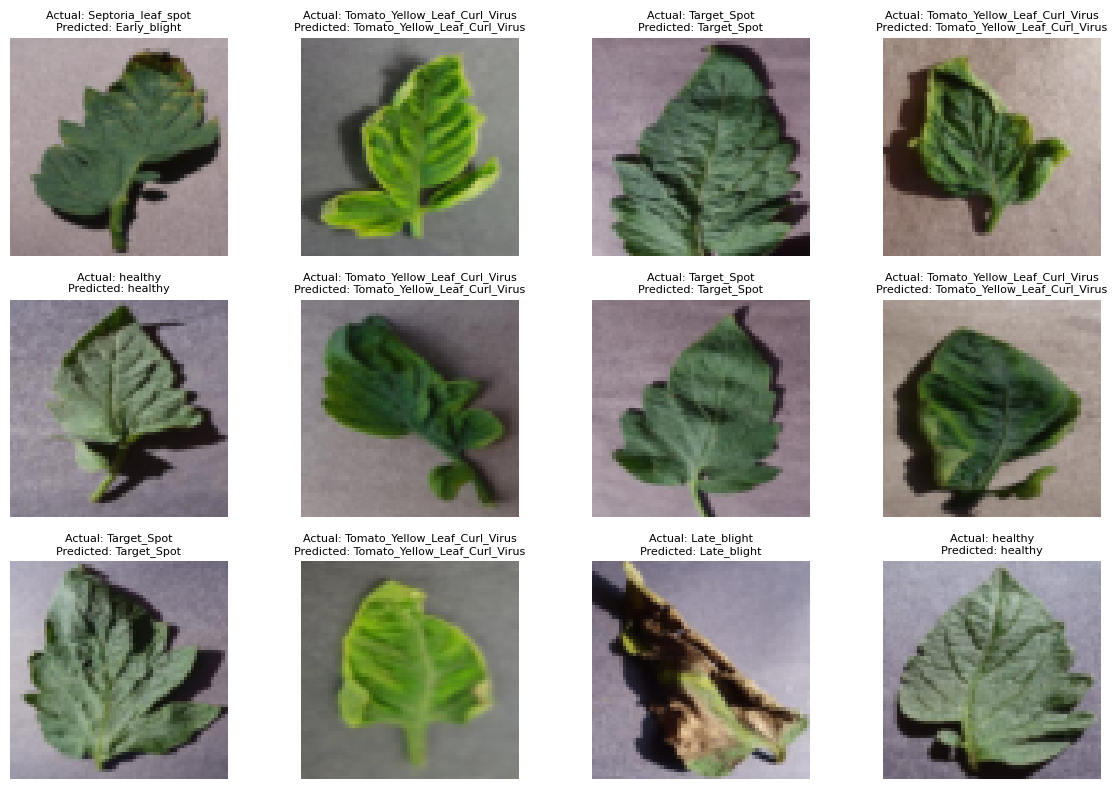

In [20]:
clean_names = [
    name.replace("Tomato___", "")
    for name in tomato_classes
]

plt.figure(figsize=(12, 8))

for i in range(12):

    image = images[i].permute(
        1, 2, 0
    )

    actual = clean_names[
        labels[i].item()
    ]

    predicted = clean_names[
        predictions[i].item()
    ]

    plt.subplot(3, 4, i + 1)

    plt.imshow(image)

    plt.title(
        f"Actual: {actual}\n"
        f"Predicted: {predicted}",
        fontsize=8
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [21]:
torch.save(
    model.state_dict(),
    "tomato_simple_cnn.pth"
)

print("Model saved!")

Model saved!


In [22]:
model = SimpleCNN(num_classes=len(tomato_classes))

model.load_state_dict(
    torch.load("tomato_simple_cnn.pth", map_location=device)
)

model = model.to(device)
model.eval()

print("Saved model loaded!")

Saved model loaded!
